# Introducing Transfer Learning

Based on the dataset we have, here are the steps that we will do:

## We will apply VGG16 pretrained model

1. reshaping the 1d data to 2d (matrix form)
2. Converting the datatype of that 2d matrix to 'np.uint8'. This is because in future, we need PIL images which requires the data to be in uint8 format
3. converting 1d to 3d
4. tensor -> PIL image
5. Resize -> (3,256,256)
6. Center crop (3,224,224)
7. Tensor -> applying scailing
8. Normalize

In [50]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [51]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device:{device}")

Using Device:cuda


In [52]:
df = pd.read_csv("fashion-mnist_train.csv")

In [53]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [54]:
df.shape

(60000, 785)

In [55]:
X = df.iloc[:,1:].values
y = df.iloc[:,0].values

In [56]:
import numpy as np
X = np.nan_to_num(X,nan=0.0)

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [58]:
# Transformation
from torchvision.transforms import transforms

custom_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

The above mean and std values were taken from the documentation of torchvision vgg16

https://docs.pytorch.org/vision/main/models/generated/torchvision.models.vgg16.html

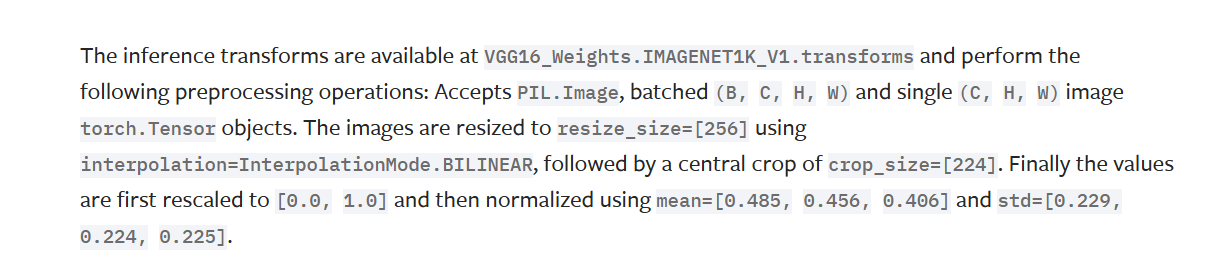

In [73]:
from PIL import Image
import numpy as np

class CustomDataset(Dataset):
  def __init__(self, features, labels, transforms):
    self.features = features
    self.labels = labels
    self.transforms = transforms

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    # all those 4 steps from the begenning
    # resize to 28*28
    image = self.features[index].reshape(28,28)

    # change datatype to np.uint8
    image = image.astype(np.uint8)

    # change black&white image to color image (simply from 1 channel to 3 channel)
    image = np.stack([image]*3, axis=-1) # copying the info 3 times by using stack func
    # axis=-1 -> converts (2,2,3) to (3,2,2)

    # convert array to PIL image
    image = Image.fromarray(image)

    # apply transformations
    image = self.transforms(image)

    # return
    return image, torch.tensor(self.labels[index], dtype=torch.long)

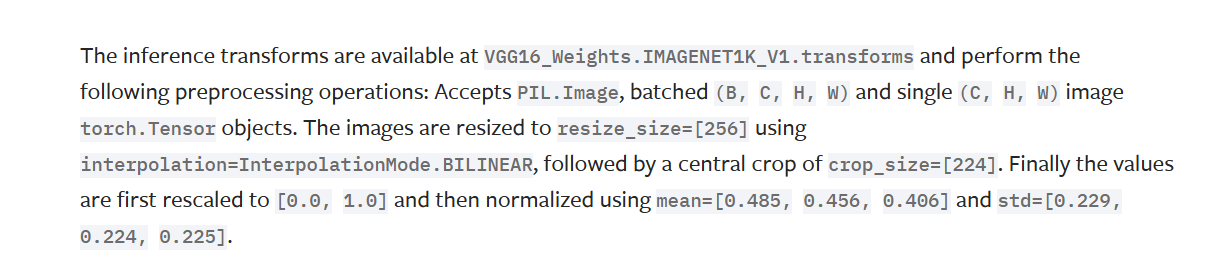

In [74]:
# create train_dataset object
train_dataset = CustomDataset(X_train, y_train, transforms=custom_transform)

In [75]:
test_dataset = CustomDataset(X_test,y_test, transforms=custom_transform)

In [76]:
# create train and test loader object
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True) # pin_memory is simply used to speed up the training on GPU
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True) # while predicting, you usually dont wanna shuffle the data.

Our architecture

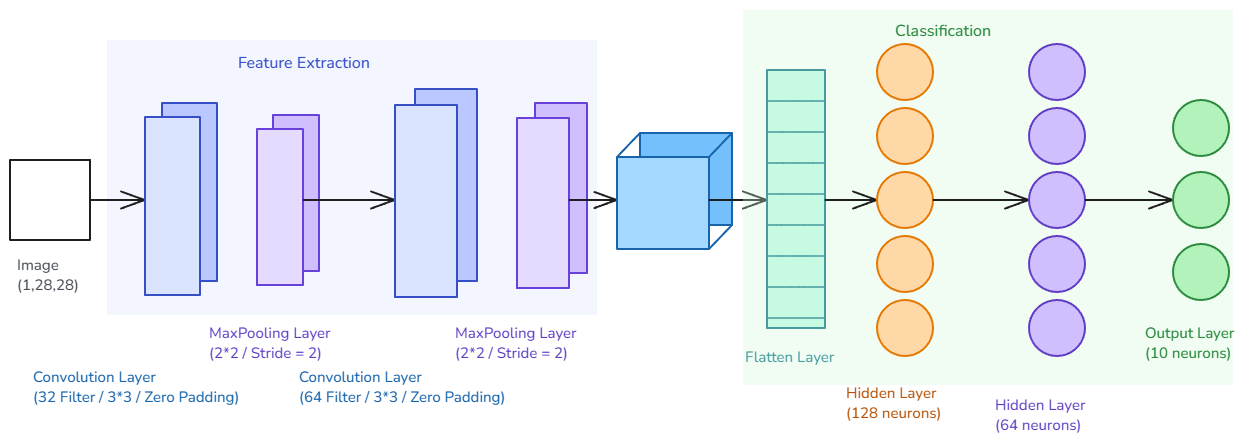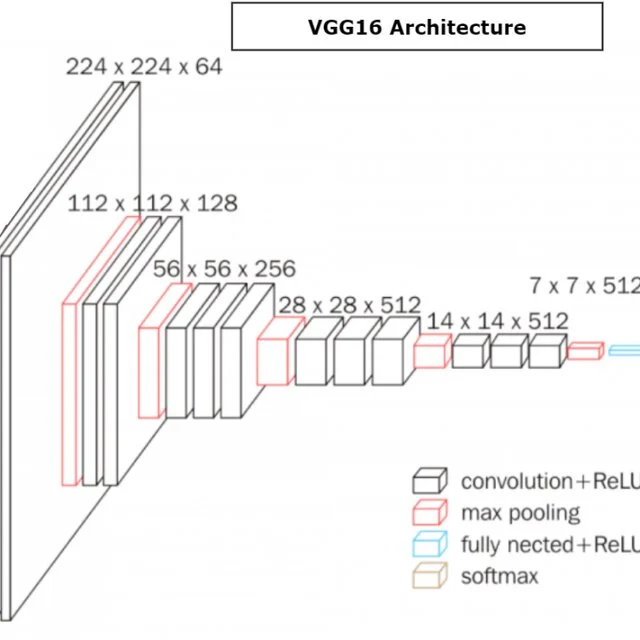

In [77]:
# fetching the pretrained model

import torchvision.models as models

vgg16 = models.vgg16(pretrained=True)

In [78]:
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [79]:
vgg16.classifier

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)

In [80]:
for param in vgg16.features.parameters():
  param.requires_grad = False

In [81]:
# now replacing the classifier with our own one

vgg16.classifier = nn.Sequential(
    nn.Linear(25088, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 10),
)

# now we have replaced the classifier in vgg16 with our own

In [82]:
vgg16

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [83]:
vgg16 = vgg16.to(device)

In [84]:
# setting learning rate and epochs
epochs = 10
learning_rate = 0.0001

In [85]:
# loss function
criterion = nn.CrossEntropyLoss()
# Optimizer
optimizer = optim.Adam(vgg16.classifier.parameters(), lr=learning_rate) # explicitly telling the optimizer to update only the classifier's parameters

In [ ]:
# training loop
for epoch in range(epochs):

  total_epoch_loss = 0 # setting up a variable in order to track the loss across each epoch

  for batch_features, batch_labels in train_loader:

    # move data to GPU
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # forward pass
    outputs = vgg16(batch_features)

    # loss calculate
    loss = criterion(outputs, batch_labels)

    # back propagation
    optimizer.zero_grad() # clearing out gradients
    loss.backward()

    # update weights
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

  avg_loss = total_epoch_loss / len(train_loader)
  print(f'Epoch: {epoch+1}, Loss : {avg_loss}')

# this will take along long time. since this is a very big architecture, even with gpu, it will take about 10 mins per epoch.

# I will stop the training since it is gonna take alot of time : )

In [ ]:
# set model to the evaluation mode
model.eval() # we have to explicitly tell the model that it's in eval mode because sometimes, some models might behave different while training and testing. for ex, dropouts.

In [ ]:
# Evaluation code
total = 0
correct = 0

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
      # move data to GPU
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        outputs = vgg16(batch_features)

        _, predicted = torch.max(outputs, 1)  # Calculates class with max probability

        total += batch_labels.shape[0]      # Accumulate total samples

        correct += (predicted == batch_labels).sum().item()  # Count correct predictions

print(f"Accuracy: {correct / total:.4f}")  # or just correct/total